# Tasmania Wave Buoy Data Investigation — Fixed vs Drifting Instruments

> *Investigate the Wave Buoy dataset around Tasmania*

---
## 0 · Setup

In [1]:
import os, requests, importlib.util

open('setup.py', 'w').write(
    requests.get(
        'https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py'
    ).text
)
spec = importlib.util.spec_from_file_location('setup', 'setup.py')
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
setup.install_requirements()
setup.load_dataquery()

Using CPython 3.13.5
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
Using Python 3.12.11 environment at: /home/lbesnard/miniforge3/envs/AodnCloudOptimised
Resolved 241 packages in 3.48s
Audited 241 packages in 1ms


⚠️ Local file has no version or is missing. Downloading remote file.
📥 Wrote updated DataQuery.py


In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DataQuery import GetAodn, plot_ts_diagram
aodn = GetAodn()

## Why Does the Buoy Location Look Scattered?

When querying the `wave_buoy_realtime_nonqc` dataset for the waters east of Tasmania, the data looks
"all over the place" — hundreds of unique latitude/longitude positions for what appears to be a single
instrument.

**This notebook investigates and explains that behaviour**, then guides you to the correct dataset
for a fixed moored buoy near Tasmania.

### Key findings (spoiler)
| Instrument | Type | Position | WHTH | WPPE |
|---|---|---|---|---|
| Wilsons Prom (Deakin Uni) | **Drifting** Spotter buoy | Changes every record | ❌ Missing | ✅ Available |
| Cape Sorell (BOM/IMOS) | **Fixed** moored buoy (W. Tasmania) | -42.20°S 145.05°E | ✅ Available | ✅ Available |

The **drifter** ends up inside a Tasmania bounding box because it was deployed near Wilsons Prom
(Victoria) and drifted ~281 km south-eastward over 22 days.


## 1. Parameters

In [3]:
import warnings, calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings('ignore')

# ── Search box that reproduces the "scattered locations" issue ────────
SEARCH_LAT_MIN = -44.6
SEARCH_LAT_MAX = -40.0
SEARCH_LON_MIN = 145.5
SEARCH_LON_MAX = 150.5
DATE_START = '2022-01-01'
DATE_END   = '2024-12-31'

# ── Cape Sorell (the real fixed Tasmania buoy) ─────────────────────
SORELL_LAT, SORELL_LON = -42.2, 145.05

print("Search box:", SEARCH_LAT_MIN, SEARCH_LAT_MAX, SEARCH_LON_MIN, SEARCH_LON_MAX)
print("Period    :", DATE_START, "→", DATE_END)

Search box: -44.6 -40.0 145.5 150.5
Period    : 2022-01-01 → 2024-12-31


## 2. Reproduce the "Weird" Bounding-Box Query

This is the code that produces the confusing scattered-location result.


In [4]:
aodn = GetAodn()
ds_wave = aodn.get_dataset('wave_buoy_realtime_nonqc.parquet')

df_bbox = ds_wave.get_data(
    lat_min=SEARCH_LAT_MIN, lat_max=SEARCH_LAT_MAX,
    lon_min=SEARCH_LON_MIN, lon_max=SEARCH_LON_MAX,
    date_start=DATE_START,  date_end=DATE_END,
)
df_bbox['TIME'] = pd.to_datetime(df_bbox['TIME'])

print(f"Records returned by bbox query : {len(df_bbox):,}")
print(f"Unique lat/lon pairs           : {df_bbox[['LATITUDE','LONGITUDE']].drop_duplicates().shape[0]}")
print(f"WHTH null fraction             : {df_bbox['WHTH'].isna().mean():.1%}")
print(f"WPPE null fraction             : {df_bbox['WPPE'].isna().mean():.1%}")
print(f"\nDate range : {df_bbox['TIME'].min().date()}  →  {df_bbox['TIME'].max().date()}")
print(f"\nsite_name unique  : {df_bbox['site_name'].unique()}")
print(f"filename  sample  : {df_bbox['filename'].iloc[0] if len(df_bbox) else 'n/a'}")

2026-03-26 11:57:05,075 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/wave_buoy_realtime_nonqc.parquet


Records returned by bbox query : 935
Unique lat/lon pairs           : 935
WHTH null fraction             : 100.0%
WPPE null fraction             : 0.0%

Date range : 2024-11-03  →  2024-11-25

site_name unique  : ['Wilsons Prom']
filename  sample  : VIC-DEAKIN-UNI_20241101_WILSONS-PROM_RT_WAVE-PARAMETERS_monthly.nc


## 3. Diagnose: Is This a Fixed or a Drifting Instrument?

A fixed moored buoy stays at essentially one coordinate. A drifting buoy changes position with every record.

In [5]:
if df_bbox.empty:
    print("No data in bbox — nothing to diagnose.")
else:
    df_sorted = df_bbox.sort_values('TIME').reset_index(drop=True)

    # Position variance
    lat_std = df_sorted['LATITUDE'].std()
    lon_std = df_sorted['LONGITUDE'].std()
    unique_pos = df_sorted[['LATITUDE','LONGITUDE']].drop_duplicates().shape[0]
    total_rec  = len(df_sorted)
    
    print(f"Position variability:")
    print(f"  Latitude  std  : {lat_std:.4f}°  ({lat_std*111:.1f} km)")
    print(f"  Longitude std  : {lon_std:.4f}°  ({lon_std*111:.1f} km)")
    print(f"  Unique positions / total records : {unique_pos} / {total_rec}")
    
    if unique_pos / total_rec > 0.5:
        verdict = "⚠️  DRIFTING buoy — position changes with almost every record"
    elif lat_std * 111 < 1:
        verdict = "✅ FIXED moored buoy — position is essentially constant"
    else:
        verdict = "⚠️  Possibly drifting or GPS-noisy instrument"
    print(f"\nVerdict: {verdict}")

    # Drift speed
    lat_d  = df_sorted['LATITUDE'].diff()
    lon_d  = df_sorted['LONGITUDE'].diff()
    dt_h   = df_sorted['TIME'].diff().dt.total_seconds() / 3600
    speed  = np.sqrt(lat_d**2 + lon_d**2) * 111 / dt_h
    total_dist = (np.sqrt(lat_d**2 + lon_d**2) * 111).sum()
    duration_days = (df_sorted['TIME'].max() - df_sorted['TIME'].min()).days

    print(f"\nDrift statistics:")
    print(f"  Mean drift speed : {speed.mean():.2f} km/h")
    print(f"  Max  drift speed : {speed.max():.2f} km/h")
    print(f"  Total distance   : {total_dist:.0f} km over {duration_days} days")
    print(f"  Start: {df_sorted['LATITUDE'].iloc[0]:.3f}°S  {df_sorted['LONGITUDE'].iloc[0]:.3f}°E")
    print(f"  End  : {df_sorted['LATITUDE'].iloc[-1]:.3f}°S  {df_sorted['LONGITUDE'].iloc[-1]:.3f}°E")

Position variability:
  Latitude  std  : 0.4752°  (52.7 km)
  Longitude std  : 0.3063°  (34.0 km)
  Unique positions / total records : 935 / 935

Verdict: ⚠️  DRIFTING buoy — position changes with almost every record

Drift statistics:
  Mean drift speed : 2.51 km/h
  Max  drift speed : 6.78 km/h
  Total distance   : 1325 km over 22 days
  Start: -40.009°S  149.270°E
  End  : -42.200°S  150.180°E


## 4. Map the Drifter Trajectory

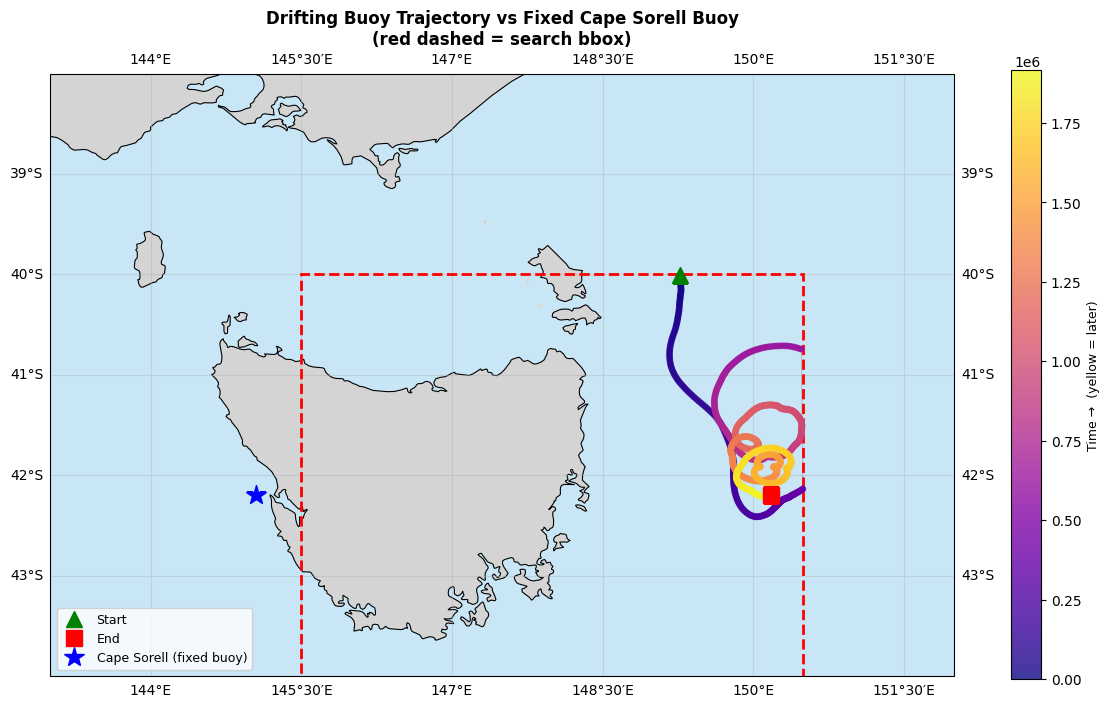


Drifter site_name : Wilsons Prom
Source file       : VIC-DEAKIN-UNI_20241101_WILSONS-PROM_RT_WAVE-PARAMETERS_monthly.nc

💡 This buoy was deployed near Wilsons Prom (Victoria) by Deakin University
   and drifted into the Tasmania bounding box — it is NOT a Tasmania buoy.


In [6]:
if df_bbox.empty:
    print("No drifter data to plot.")
else:
    df_sorted = df_bbox.sort_values('TIME').reset_index(drop=True)

    fig = plt.figure(figsize=(12, 9))
    ax  = fig.add_subplot(111, projection=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.LAND,  facecolor='#d4d4d4')
    ax.add_feature(cfeature.OCEAN, facecolor='#c8e6f5')
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.4)

    # Colour the drift track by time
    times_num = (df_sorted['TIME'] - df_sorted['TIME'].min()).dt.total_seconds()
    sc = ax.scatter(df_sorted['LONGITUDE'], df_sorted['LATITUDE'],
                    c=times_num, cmap='plasma', s=15, alpha=0.8,
                    transform=ccrs.PlateCarree(), zorder=4)
    ax.plot(df_sorted['LONGITUDE'], df_sorted['LATITUDE'],
            '-', lw=0.6, color='grey', alpha=0.5, transform=ccrs.PlateCarree())

    # Mark start and end
    ax.plot(df_sorted['LONGITUDE'].iloc[0],  df_sorted['LATITUDE'].iloc[0],
            'g^', markersize=12, transform=ccrs.PlateCarree(), zorder=5, label='Start')
    ax.plot(df_sorted['LONGITUDE'].iloc[-1], df_sorted['LATITUDE'].iloc[-1],
            'rs', markersize=12, transform=ccrs.PlateCarree(), zorder=5, label='End')

    # Cape Sorell fixed buoy
    ax.plot(SORELL_LON, SORELL_LAT, 'b*', markersize=15, transform=ccrs.PlateCarree(),
            zorder=6, label='Cape Sorell (fixed buoy)')

    # Search box
    from matplotlib.patches import Rectangle
    search_rect = plt.Polygon(
        [[SEARCH_LON_MIN, SEARCH_LAT_MIN],[SEARCH_LON_MAX, SEARCH_LAT_MIN],
         [SEARCH_LON_MAX, SEARCH_LAT_MAX],[SEARCH_LON_MIN, SEARCH_LAT_MAX]],
        fill=False, edgecolor='red', linewidth=2, linestyle='--',
        transform=ccrs.PlateCarree(), zorder=3)
    ax.add_patch(search_rect)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, label='Time (seconds from start)')
    cbar.set_label('Time →  (yellow = later)', fontsize=9)

    ax.set_extent([143, 152, -44, -38], crs=ccrs.PlateCarree())
    ax.set_title('Drifting Buoy Trajectory vs Fixed Cape Sorell Buoy\n'
                 '(red dashed = search bbox)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()

    site = df_sorted['site_name'].iloc[0]
    fname = df_sorted['filename'].iloc[0]
    print(f"\nDrifter site_name : {site}")
    print(f"Source file       : {fname}")
    print(f"\n💡 This buoy was deployed near Wilsons Prom (Victoria) by Deakin University")
    print(f"   and drifted into the Tasmania bounding box — it is NOT a Tasmania buoy.")

## 5. Drifter Data Quality: What Variables Are Actually Available?

In [7]:
if not df_bbox.empty:
    wave_vars = ['WHTH', 'WSSH', 'WPPE', 'WPMH', 'WMXH', 'WPDI', 'WAVE_quality_control']
    print("Variable availability in the drifter records:")
    print(f"  {'Variable':<30}  {'Non-null':>10}  {'Null %':>8}  {'Mean':>10}")
    print("  " + "-" * 65)
    for v in wave_vars:
        if v in df_bbox.columns:
            nn = df_bbox[v].notna().sum()
            pct = df_bbox[v].isna().mean() * 100
            mean_v = df_bbox[v].mean() if df_bbox[v].dtype in [float, int] else "n/a"
            mean_str = f"{mean_v:10.3f}" if isinstance(mean_v, float) else f"{'n/a':>10}"
            print(f"  {v:<30}  {nn:>10,}  {pct:>7.1f}%  {mean_str}")

    print(f"\n⚠️  WHTH (significant wave height) is entirely missing.")
    print(f"   Only WPPE (peak wave period) is reported by this drifter.")
    print(f"\n   Likely cause: the Spotter buoy was in transit/delivery mode,")
    print(f"   or the wave height algorithm was not yet activated.")

Variable availability in the drifter records:
  Variable                          Non-null    Null %        Mean
  -----------------------------------------------------------------
  WHTH                                     0    100.0%         nan
  WSSH                                   935      0.0%       2.435
  WPPE                                   935      0.0%      10.684
  WPMH                                     0    100.0%         nan
  WMXH                                     0    100.0%         nan
  WPDI                                   935      0.0%     168.799
  WAVE_quality_control                   935      0.0%         n/a

⚠️  WHTH (significant wave height) is entirely missing.
   Only WPPE (peak wave period) is reported by this drifter.

   Likely cause: the Spotter buoy was in transit/delivery mode,
   or the wave height algorithm was not yet activated.


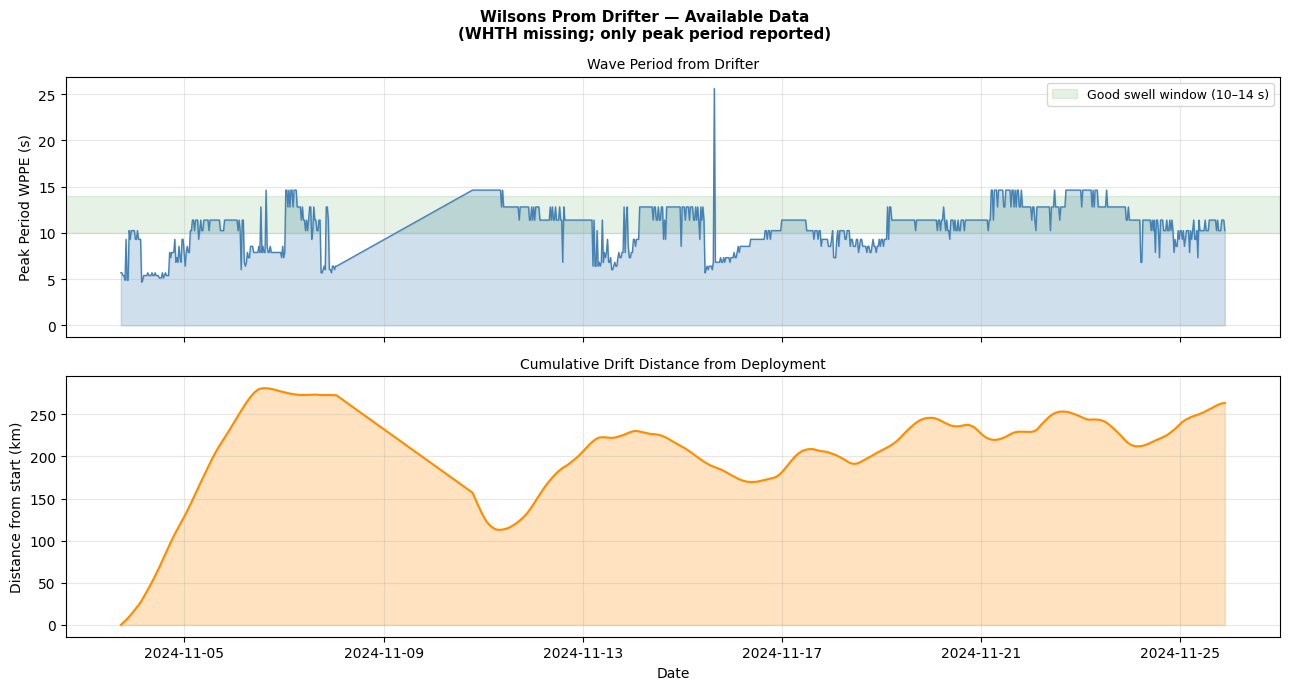

In [8]:
if not df_bbox.empty:
    # Plot the only useful variable from the drifter: WPPE
    df_d = df_bbox.sort_values('TIME')
    
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    fig.suptitle('Wilsons Prom Drifter — Available Data\n(WHTH missing; only peak period reported)',
                 fontsize=11, fontweight='bold')
    
    ax = axes[0]
    ax.plot(df_d['TIME'], df_d['WPPE'], 'steelblue', lw=1)
    ax.fill_between(df_d['TIME'], df_d['WPPE'], alpha=0.25, color='steelblue')
    ax.set_ylabel('Peak Period WPPE (s)', fontsize=10)
    ax.set_title('Wave Period from Drifter', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhspan(10, 14, alpha=0.1, color='green', label='Good swell window (10–14 s)')
    ax.legend(fontsize=9)
    
    ax = axes[1]
    dist_from_start = (
        np.sqrt((df_d['LATITUDE'] - df_d['LATITUDE'].iloc[0])**2 +
                (df_d['LONGITUDE'] - df_d['LONGITUDE'].iloc[0])**2) * 111
    )
    ax.plot(df_d['TIME'], dist_from_start, 'darkorange', lw=1.5)
    ax.fill_between(df_d['TIME'], dist_from_start, alpha=0.25, color='darkorange')
    ax.set_ylabel('Distance from start (km)', fontsize=10)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_title('Cumulative Drift Distance from Deployment', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. The Correct Approach: Load Cape Sorell Fixed Buoy

**Cape Sorell** (-42.20°S, 145.05°E) is the proper fixed moored buoy on the west coast of Tasmania.
Query it directly using a tight bounding box or `scalar_filter={'site_name': 'Cape Sorell'}`.


In [9]:
# ── Option A: tight bbox around Cape Sorell ───────────────────────
df_sorell = ds_wave.get_data(
    lat_min=-42.5, lat_max=-41.9,
    lon_min=144.7, lon_max=145.4,
    date_start=DATE_START, date_end=DATE_END,
)
df_sorell['TIME'] = pd.to_datetime(df_sorell['TIME'])

# Verify it's truly fixed
pos_sorell = df_sorell[['LATITUDE','LONGITUDE']].drop_duplicates()
print(f"Cape Sorell records  : {len(df_sorell):,}")
print(f"Unique positions     : {len(pos_sorell)}")
print(f"Lat std  (m)         : {df_sorell['LATITUDE'].std()*111*1000:.1f} m")
print(f"Lon std  (m)         : {df_sorell['LONGITUDE'].std()*111*1000:.1f} m")
print(f"Date range           : {df_sorell['TIME'].min().date()} → {df_sorell['TIME'].max().date()}")
print(f"\nWHTH (Hs)  — mean: {df_sorell['WHTH'].mean():.2f} m  max: {df_sorell['WHTH'].max():.2f} m")
print(f"WPPE (Tp)  — mean: {df_sorell['WPPE'].mean():.2f} s  max: {df_sorell['WPPE'].max():.2f} s")
print(f"WMXH (Hmax)— mean: {df_sorell['WMXH'].mean():.2f} m  max: {df_sorell['WMXH'].max():.2f} m")

2026-03-26 11:57:09,194 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/wave_buoy_realtime_nonqc.parquet


Cape Sorell records  : 15,233
Unique positions     : 1
Lat std  (m)         : 0.0 m
Lon std  (m)         : 0.0 m
Date range           : 2022-11-06 → 2024-12-30

WHTH (Hs)  — mean: 3.04 m  max: 10.55 m
WPPE (Tp)  — mean: 12.49 s  max: 20.00 s
WMXH (Hmax)— mean: 4.80 m  max: 17.82 m


## 7. Cape Sorell — Full Wave Analysis

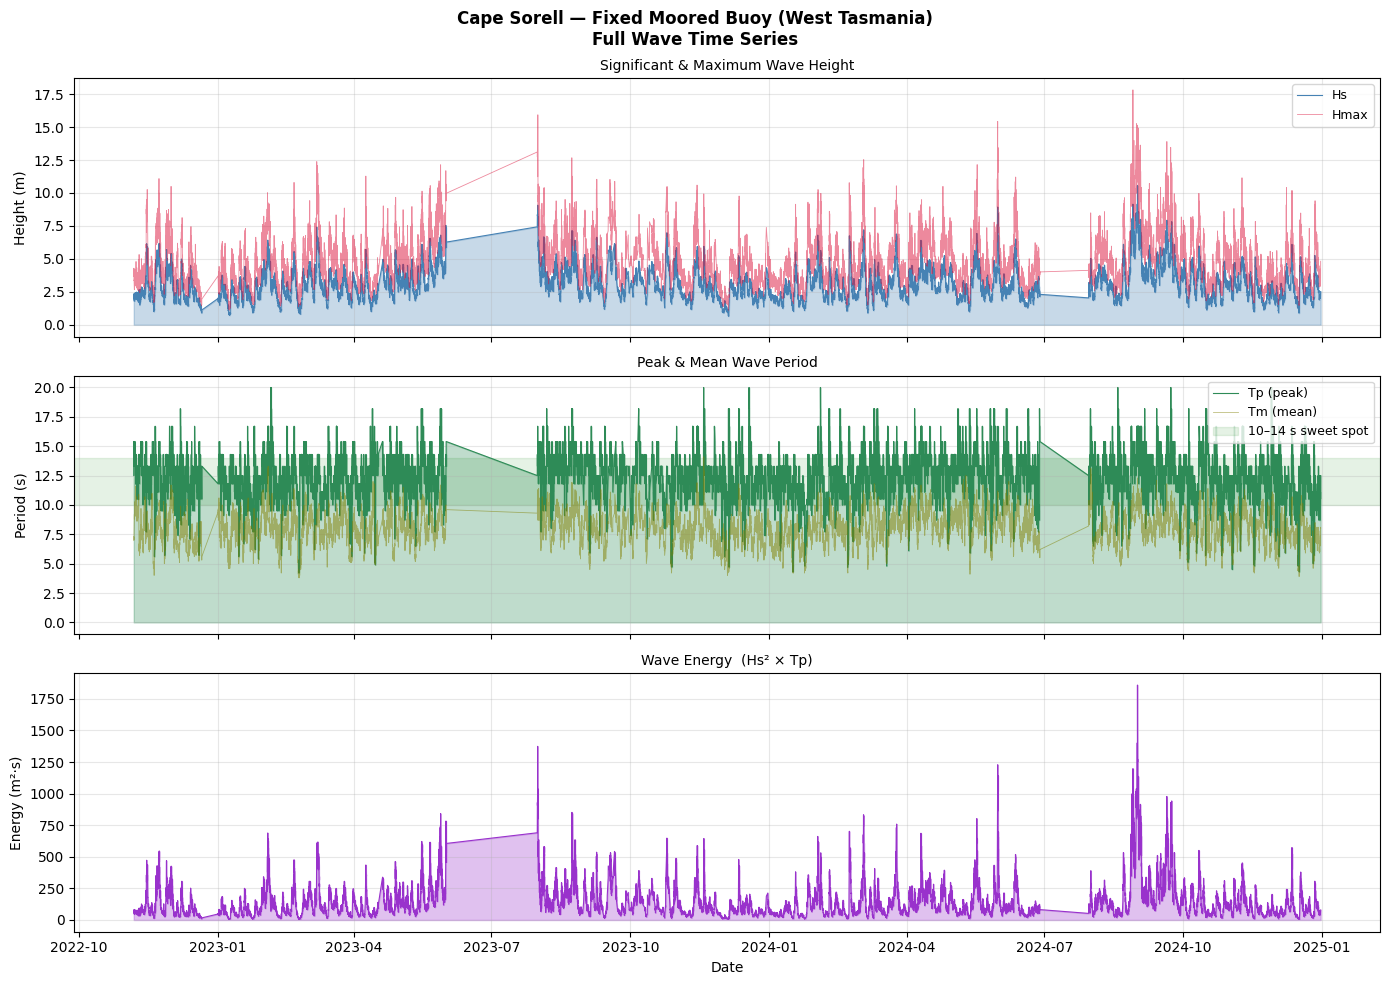

In [10]:
if df_sorell.empty:
    print("No Cape Sorell data — check bbox or date range.")
else:
    df_s = df_sorell[df_sorell['WHTH'].notna()].sort_values('TIME').copy()
    df_s['energy'] = df_s['WHTH']**2 * df_s['WPPE']
    df_s['month']  = df_s['TIME'].dt.month

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Cape Sorell — Fixed Moored Buoy (West Tasmania)\nFull Wave Time Series',
                 fontsize=12, fontweight='bold')

    ax = axes[0]
    ax.fill_between(df_s['TIME'], df_s['WHTH'], alpha=0.3, color='steelblue')
    ax.plot(df_s['TIME'], df_s['WHTH'], lw=0.8, color='steelblue', label='Hs')
    ax.plot(df_s['TIME'], df_s['WMXH'], lw=0.6, color='crimson', alpha=0.5, label='Hmax')
    ax.set_ylabel('Height (m)', fontsize=10)
    ax.set_title('Significant & Maximum Wave Height', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.fill_between(df_s['TIME'], df_s['WPPE'], alpha=0.3, color='seagreen')
    ax.plot(df_s['TIME'], df_s['WPPE'], lw=0.8, color='seagreen', label='Tp (peak)')
    ax.plot(df_s['TIME'], df_s['WPMH'], lw=0.6, color='olive', alpha=0.5, label='Tm (mean)')
    ax.axhspan(10, 14, alpha=0.1, color='green', label='10–14 s sweet spot')
    ax.set_ylabel('Period (s)', fontsize=10)
    ax.set_title('Peak & Mean Wave Period', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.fill_between(df_s['TIME'], df_s['energy'], alpha=0.3, color='darkorchid')
    ax.plot(df_s['TIME'], df_s['energy'], lw=0.8, color='darkorchid')
    ax.set_ylabel('Energy (m²·s)', fontsize=10)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_title('Wave Energy  (Hs² × Tp)', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Monthly Climatology — Cape Sorell

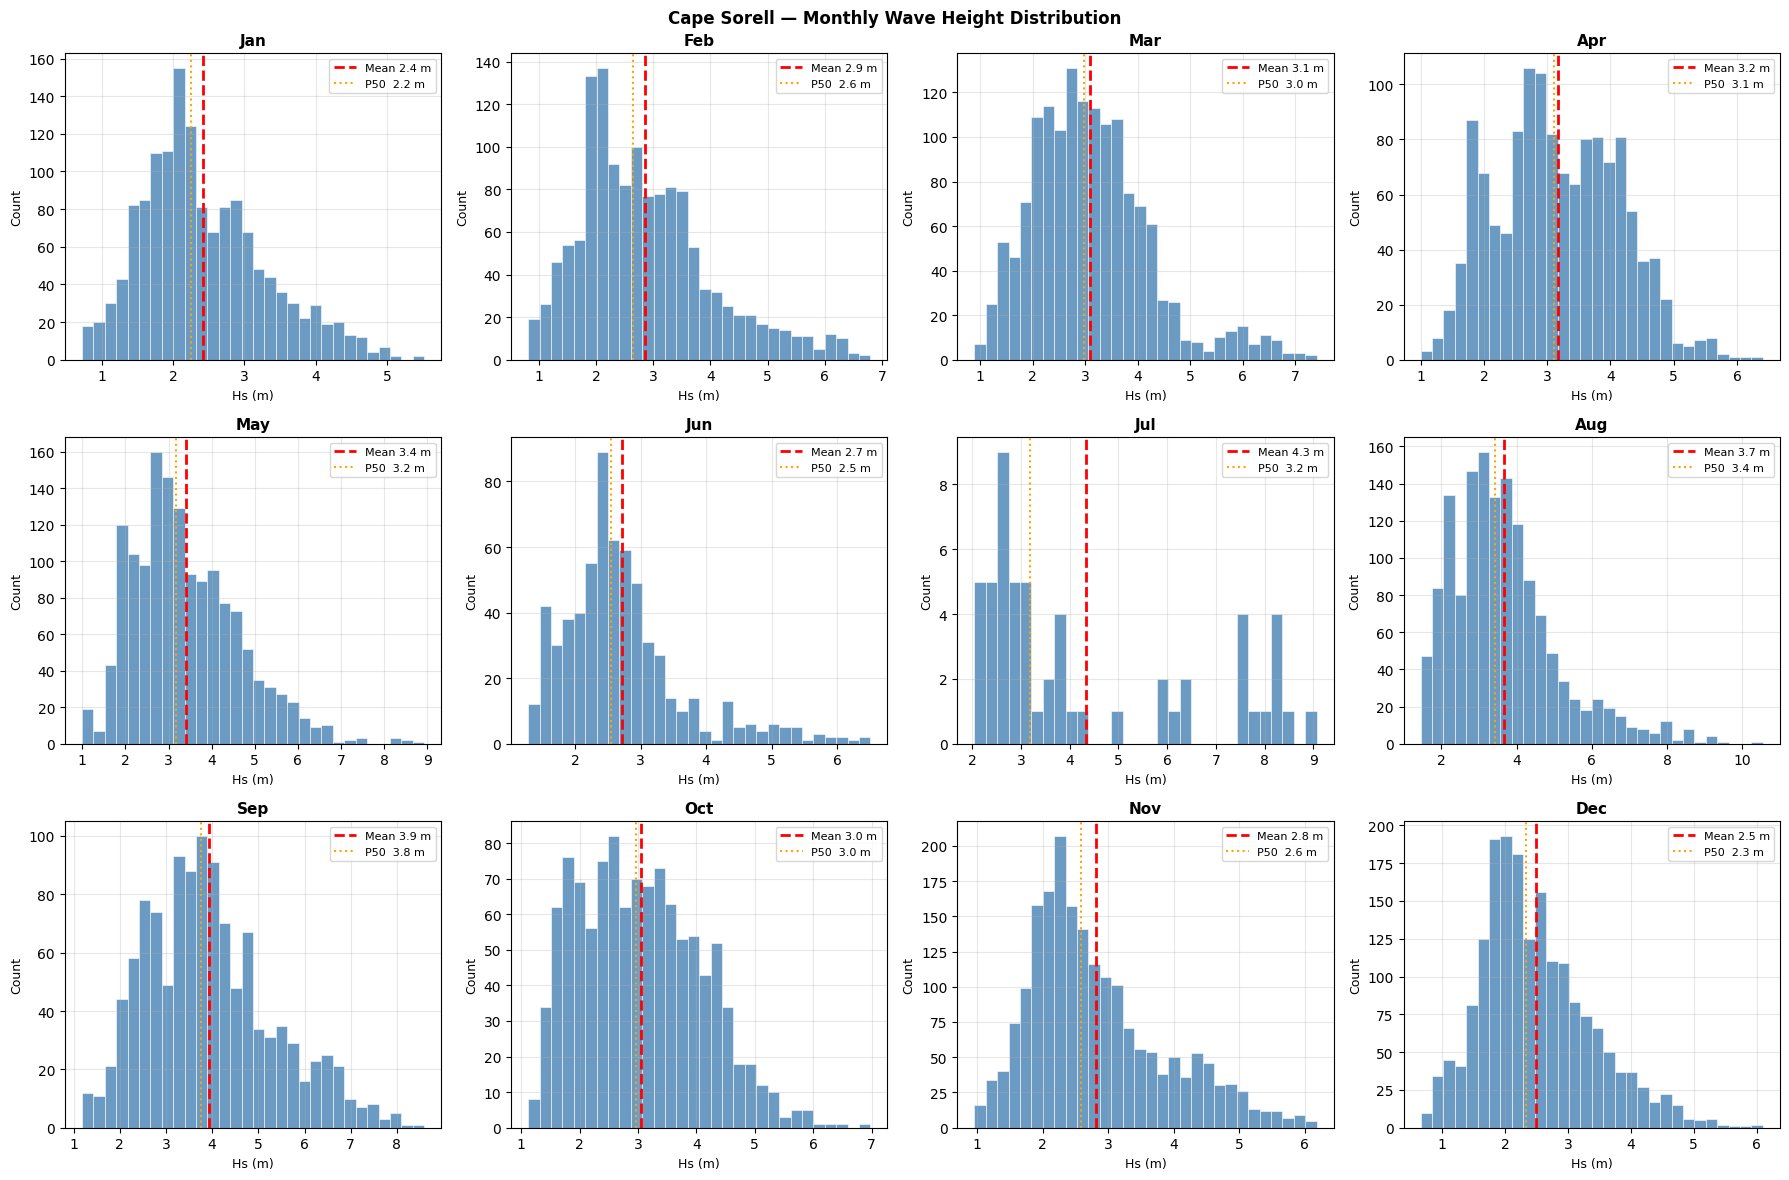


Monthly summary  (Cape Sorell):
  Month       N   Hs_mean    Hs_p90    Hs_max   Tp_mean   Energy_mean
  ----------------------------------------------------------------------
  Jan      1449      2.42      3.65      5.52      11.7          79.7
  Feb      1345      2.85      4.52      6.80      12.1         122.4
  Mar      1454      3.10      4.37      7.41      12.5         141.3
  Apr      1315      3.17      4.38      6.41      12.8         142.6
  May      1466      3.40      5.09      8.93      13.0         174.4
  Jun       632      2.71      3.87      6.51      12.7         102.0
  Jul        56      4.33      8.12      9.07      14.0         343.5
  Aug      1435      3.66      5.48     10.55      13.2         210.2
  Sep      1153      3.93      5.95      8.59      13.1         237.4
  Oct      1109      3.04      4.43      6.98      12.3         131.0
  Nov      1967      2.82      4.42      6.18      12.5         115.7
  Dec      1852      2.49      3.71      6.10      11.

In [11]:
if not df_sorell.empty:
    df_s = df_sorell[df_sorell['WHTH'].notna()].copy()
    df_s['month'] = df_s['TIME'].dt.month
    
    months_present = sorted(df_s['month'].unique())
    if not months_present:
        print("No data with valid WHTH.")
    else:
        n_months = len(months_present)
        n_cols   = min(n_months, 4)
        n_rows   = -(-n_months // n_cols)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows),
                                 sharey=False)
        axes = np.array(axes).flatten()
        fig.suptitle('Cape Sorell — Monthly Wave Height Distribution',
                     fontsize=12, fontweight='bold')
        
        for i, m in enumerate(months_present):
            ax  = axes[i]
            d_m = df_s[df_s['month'] == m]['WHTH'].dropna()
            if d_m.empty:
                ax.set_visible(False)
                continue
            ax.hist(d_m, bins=30, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.5)
            ax.axvline(d_m.mean(),  color='red',    lw=2, linestyle='--', label=f'Mean {d_m.mean():.1f} m')
            ax.axvline(d_m.median(),color='orange', lw=1.5, linestyle=':', label=f'P50  {d_m.median():.1f} m')
            ax.set_title(calendar.month_abbr[m], fontsize=11, fontweight='bold')
            ax.set_xlabel('Hs (m)', fontsize=9)
            ax.set_ylabel('Count', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        
        for j in range(len(months_present), len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Print table
        print("\nMonthly summary  (Cape Sorell):")
        print(f"  {'Month':<6} {'N':>6}  {'Hs_mean':>8}  {'Hs_p90':>8}  {'Hs_max':>8}  {'Tp_mean':>8}  {'Energy_mean':>12}")
        print("  " + "-" * 70)
        for m in months_present:
            d_m  = df_s[df_s['month'] == m]
            eng  = (d_m['WHTH']**2 * d_m['WPPE']).mean()
            print(f"  {calendar.month_abbr[m]:<6} {len(d_m):>6}  {d_m['WHTH'].mean():>8.2f}  "
                  f"{d_m['WHTH'].quantile(0.9):>8.2f}  {d_m['WHTH'].max():>8.2f}  "
                  f"{d_m['WPPE'].mean():>8.1f}  {eng:>12.1f}")

## 9. Side-by-Side Comparison: Drifter vs Fixed Buoy

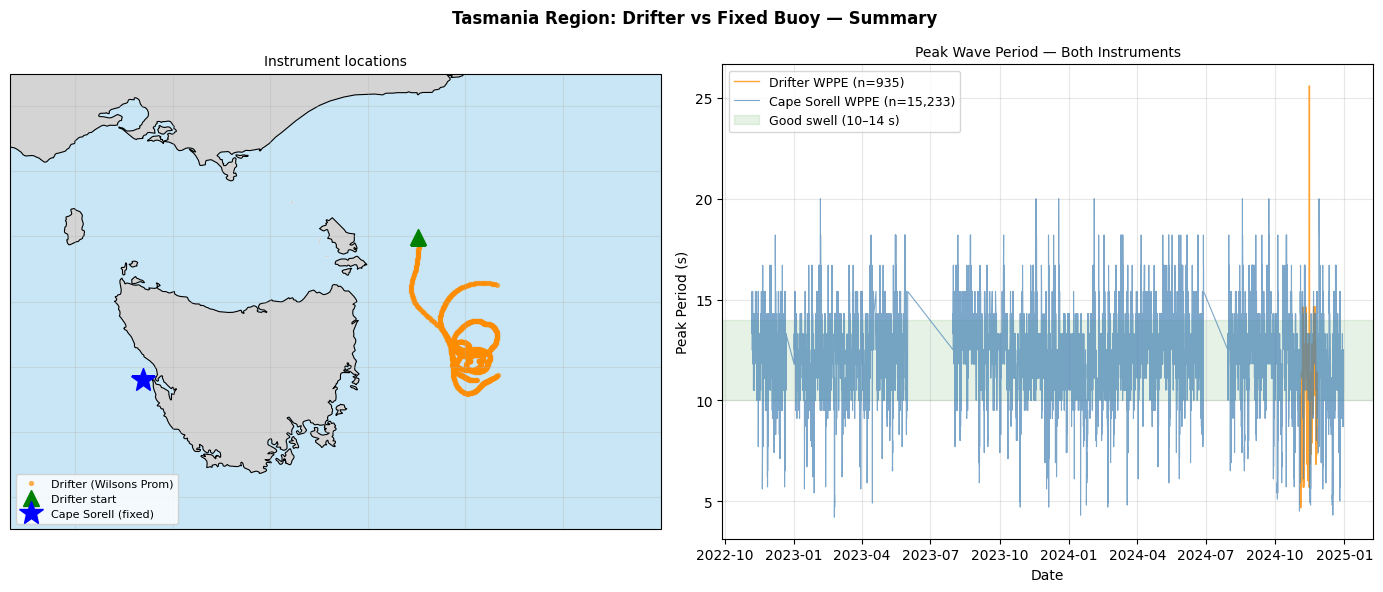


Summary comparison:
  Instrument                      Type         Records      WHTH      WPPE
  ----------------------------------------------------------------------
  Wilsons Prom drifter            DRIFTING         935    MISSING      10.7 s
  Cape Sorell                     FIXED         15,233      3.04 m      12.5 s


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tasmania Region: Drifter vs Fixed Buoy — Summary', fontsize=12, fontweight='bold')

# Left: map
ax = axes[0]
ax_map = fig.add_subplot(121, projection=ccrs.PlateCarree())
axes[0].remove()

ax_map.coastlines(resolution='10m', linewidth=0.8)
ax_map.add_feature(cfeature.LAND,  facecolor='#d4d4d4')
ax_map.add_feature(cfeature.OCEAN, facecolor='#c8e6f5')
ax_map.gridlines(alpha=0.3)

if not df_bbox.empty:
    df_d2 = df_bbox.sort_values('TIME')
    ax_map.scatter(df_d2['LONGITUDE'], df_d2['LATITUDE'], s=8, alpha=0.6,
                   c='darkorange', label='Drifter (Wilsons Prom)', transform=ccrs.PlateCarree())
    ax_map.plot(df_d2['LONGITUDE'].iloc[0], df_d2['LATITUDE'].iloc[0], 'g^',
                markersize=12, transform=ccrs.PlateCarree(), label='Drifter start')

ax_map.plot(SORELL_LON, SORELL_LAT, 'b*', markersize=18, transform=ccrs.PlateCarree(),
            zorder=6, label='Cape Sorell (fixed)')
ax_map.set_extent([143, 153, -44.5, -37.5], crs=ccrs.PlateCarree())
ax_map.set_title('Instrument locations', fontsize=10)
ax_map.legend(loc='lower left', fontsize=8)

# Right: WPPE comparison (only variable both have)
ax2 = axes[1]
if not df_bbox.empty:
    df_d2 = df_bbox.sort_values('TIME')
    ax2.plot(df_d2['TIME'], df_d2['WPPE'], color='darkorange', lw=1, alpha=0.8,
             label=f'Drifter WPPE (n={len(df_d2):,})')
if not df_sorell.empty:
    df_s2 = df_sorell[df_sorell['WPPE'].notna()].sort_values('TIME')
    ax2.plot(df_s2['TIME'], df_s2['WPPE'], color='steelblue', lw=0.8, alpha=0.7,
             label=f'Cape Sorell WPPE (n={len(df_s2):,})')
ax2.axhspan(10, 14, alpha=0.1, color='green', label='Good swell (10–14 s)')
ax2.set_ylabel('Peak Period (s)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.set_title('Peak Wave Period — Both Instruments', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSummary comparison:")
print(f"  {'Instrument':<30}  {'Type':<10}  {'Records':>8}  {'WHTH':>8}  {'WPPE':>8}")
print("  " + "-" * 70)
if not df_bbox.empty:
    print(f"  {'Wilsons Prom drifter':<30}  {'DRIFTING':<10}  {len(df_bbox):>8,}  "
          f"  {'MISSING':>6}  {df_bbox['WPPE'].mean():>8.1f} s")
if not df_sorell.empty:
    print(f"  {'Cape Sorell':<30}  {'FIXED':<10}  {len(df_sorell):>8,}  "
          f"  {df_sorell['WHTH'].mean():>6.2f} m  {df_sorell['WPPE'].mean():>8.1f} s")

## 10. Key Takeaways & Recommended Queries

### Why the data looked "scattered"

The `wave_buoy_realtime_nonqc` dataset contains **both fixed moored buoys and free-drifting Spotter buoys**.
A simple lat/lon bounding box query returns **all instruments whose track ever entered that box** —
including drifters that passed through.

| Symptom | Cause |
|---|---|
| Hundreds of unique lat/lon positions | Drifting buoy — position updates with every observation |
| `WHTH` is 100% NaN | Spotter buoy in transit / wave height algorithm not activated |
| Only 22 days of data | Short deployment / drifter eventually left the area |
| `site_name = 'Wilsons Prom'` | Originally deployed near Wilsons Promontory, Victoria |

### How to get clean fixed-buoy data for Tasmania

```python
# Option 1 — tight bbox around Cape Sorell (west Tasmania)
df = ds_wave.get_data(
    lat_min=-42.5, lat_max=-41.9,
    lon_min=144.7, lon_max=145.4,
    date_start='2022-01-01', date_end='2024-12-31',
)

# Option 2 — scalar filter on site name (fastest, uses Parquet partition pruning)
df = ds_wave.get_data(
    date_start='2022-01-01', date_end='2024-12-31',
    scalar_filter={'site_name': 'Cape Sorell'},
)
```

### How to detect drifters programmatically

```python
lat_std_km = df.groupby('site_name')['LATITUDE'].std() * 111
drifters   = lat_std_km[lat_std_km > 5].index.tolist()   # > 5 km std → likely drifting
fixed      = lat_std_km[lat_std_km <= 5].index.tolist()
```

### Available fixed buoys near Tasmania (in this dataset)
| Site | Lat | Lon | Notes |
|---|---|---|---|
| **Cape Sorell** | -42.20°S | 145.05°E | BOM/IMOS, west coast, data from Nov 2022 |
